# 🌿 VedaVision — Module 2
# Notebook 02 — Preprocessing Pipeline (v2)
### HSV/LAB Threshold → Fill-Holes → Largest Contour → Crop → Shadow Correction

---
**Input**  : `dataset/original/species_name/top/*.jpg` and `species_name/bottom/*.jpg`

**Output** : `dataset/preprocessed/species_name/top/*.jpg` and `species_name/bottom/*.jpg`

---
### Pipeline:
```
Original Image
      |
  1.  Resize                    -> 512x512 working size
  2.  Convert to HSV, extract Saturation channel
  3.  Otsu auto-threshold        -> candidate leaf / background split
  4.  Invert -> Fill Holes -> Invert (border-connectivity), WITH a
      bridge-break step first -- see note below, this is the fix for
      the white-dot problem
  5.  Component-level dark/bright classification of enclosed regions
      -> only genuinely DARK enclosed blobs (shadow crevices) removed;
         bright ones (highlights, pale leaf) protected
  6.  Remove small blobs (noise / speckle)
  7.  Morphological close + open (clean edges)
  8.  Keep largest leaf contour(s) -- drops any small floating debris,
      keeps multiple lobes if a deep notch splits the mask
  9.  Crop to leaf bounding box (removes camera-distance artifact)
  10. Illumination-correct any shadow still on the leaf surface
      (NOT inpainting -- see note below)
  11. Apply mask, replace background with white
  12. CLAHE (LAB L channel, once)
  13. Light denoising (bilateral, edge-preserving) + edge trim
  14. Resize to 224x224
```
---
### Why the classic "Invert → Fill Holes → Invert" method gives white dots

The classic ImageJ macro (Saturation threshold, then Invert/Fill Holes/
Invert to clean the mask) works well for a clean object on a clean
background, but it has one structural weakness: **fill-holes only asks
"is this background region connected to the image border or not?"** —
it doesn't ask *how* it's connected.

If a leaf has any natural low-saturation surface feature — sun-bleaching,
fine hair/fuzz, a pale disease patch, a specular highlight — and that
patch happens to connect to the real background outside the leaf via
even a single-pixel-wide path (a thin sliver where the mask is slightly
imperfect), flood-fill will follow that hairline connection and treat
the ENTIRE patch as real background, wiping out a chunk of genuine leaf
tissue. This is very likely what's producing your white dots/patches —
they are not random noise, they are real leaf-surface features that
got swept into the same connected component as the actual background
through a thin, easy-to-miss bridge.

**The fix applied below:** erode the candidate-background mask by a
few pixels *before* flood-filling (this breaks any thin hairline
bridges, since a real, wide background region survives erosion but a
1-2px-wide connecting sliver does not), flood-fill on the eroded
version, then dilate the result back out and intersect with the
original candidate mask. True background is unaffected; a deep pale
patch that was only ever connected through a hairline sliver is now
correctly excluded from "border-connected background" and gets
evaluated on its own merits by the dark/bright + area rules in step 5
instead of being wiped out unconditionally.

---
### Why illumination correction, not inpainting, for shadow ON the leaf
`cv2.inpaint()` FABRICATES pixel values for a shadowed region, guessed
from surrounding pixels — this destroys real texture (veins, surface
roughness) and replaces it with a smooth interpolated blend. Tested
directly earlier in this project: inpainting left LESS texture signal
behind than the shadow itself had. Illumination correction instead
estimates a smooth "lighting map" (shadow is a slow, low-frequency
brightness dip) and divides it out, rescaling REAL pixels back up —
no pixel is ever invented, so fine texture survives.

---
### A modern alternative (see Cell 5b)
Everything above is still fundamentally *threshold-based* — it makes
per-pixel colour decisions. A genuinely different approach is a
**learned salient-object segmentation model** (e.g. `rembg`, built on
U^2-Net), which segments based on learned visual features of "what an
object looks like" rather than colour/saturation rules at all. It has
no white-dot failure mode of this kind, because it was never reasoning
about saturation in the first place. Cell 5b shows this as a drop-in
alternative to Cell 5's `segment_leaf()` — swap it in if the threshold
approach still struggles on a particularly mottled/textured species.

---
### Run Order:
```
01_Augmentation.ipynb  ->  02_Preprocessing.ipynb  ->  04_Feature_Extraction.ipynb
```
---


## Cell 1 — Install Libraries

In [ ]:
!pip install opencv-python-headless scikit-image matplotlib numpy tqdm pandas -q
print('✅ Libraries installed!')

## Cell 2 — Import Libraries

In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import gc
from glob import glob
from tqdm import tqdm

print('✅ All libraries imported!')

✅ All libraries imported!


## Cell 3 — Mount Google Drive & Configure Paths
**Only change things in this cell — everything else runs automatically.**

In [2]:
# ============================================================
# ✏️  UPDATE THESE PATHS
# ============================================================
AUGMENTED_PATH    = 'C:/Users/User/Documents/UOM/L4S2/Research/raw'
PREPROCESSED_PATH = 'C:/Users/User/Documents/UOM/L4S2/Research/preprocess2'
LOGS_PATH         = 'C:/Users/User/Documents/UOM/L4S2/Research/logs'

VIEWS       = ['top', 'bottom']
WORK_SIZE   = (512, 512)
TARGET_SIZE = (224, 224)
# ============================================================

os.makedirs(PREPROCESSED_PATH, exist_ok=True)
os.makedirs(LOGS_PATH,         exist_ok=True)

species_list = sorted([
    d for d in os.listdir(AUGMENTED_PATH)
    if os.path.isdir(os.path.join(AUGMENTED_PATH, d))
    and not d.startswith('.')
])

print(f'✅ Drive mounted!')
print(f'📁 Input  : {AUGMENTED_PATH}')
print(f'📁 Output : {PREPROCESSED_PATH}')
print(f'🌿 Species: {species_list}')
print(f'📂 Views  : {VIEWS}')

✅ Drive mounted!
📁 Input  : C:/Users/User/Documents/UOM/L4S2/Research/raw
📁 Output : C:/Users/User/Documents/UOM/L4S2/Research/preprocess2
🌿 Species: ['Diya_Na', 'Gammiris', 'Ingini', 'Iriveriya', 'Kapparawalliya', 'Kora_Kaha', 'Kuringchan', 'Masbadda', 'Na', 'Rathu_Koboleela', 'Sudu_Koboleela', 'Wali_Kaha']
📂 Views  : ['top', 'bottom']


## Cell 4 — Helper Functions

In [3]:
def bgr2rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def get_images(base_path, species, view):
    return (
        glob(os.path.join(base_path, species, view, '*.jpg'))  +
        glob(os.path.join(base_path, species, view, '*.jpeg')) +
        glob(os.path.join(base_path, species, view, '*.png'))
    )

print('✅ Helper functions defined!')

✅ Helper functions defined!


## Cell 5 — Segmentation & Preprocessing Functions

In [4]:
def resize_with_padding(image, target_size, pad_value=255):
    """Resize preserving aspect ratio, pad the rest with white."""
    h, w = image.shape[:2]
    target_w, target_h = target_size

    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))
    resized = cv2.resize(image, (new_w, new_h))

    # center on a padded canvas
    canvas = np.full((target_h, target_w, 3), pad_value, dtype=np.uint8)
    x_off = (target_w - new_w) // 2
    y_off = (target_h - new_h) // 2
    canvas[y_off:y_off+new_h, x_off:x_off+new_w] = resized
    return canvas

def get_border_connected_background(candidate_bg, bridge_break_px=7):
    """
    Flood-fills candidate_bg in from the image border to find TRUE
    background, with a bridge-break step first: eroding candidate_bg
    by bridge_break_px before flood-filling breaks any thin (1-2px)
    hairline connection between real background and a pale patch deep
    inside the leaf, so the fill can't "leak" through it. The result is
    dilated back out and intersected with the original candidate mask,
    so true background extent is preserved -- only the leaked tendrils
    into the leaf are cut off.
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (bridge_break_px, bridge_break_px))
    eroded_bg = cv2.erode(candidate_bg, kernel)

    h, w = eroded_bg.shape
    padded = cv2.copyMakeBorder(eroded_bg, 1, 1, 1, 1, cv2.BORDER_CONSTANT, value=255)
    flood_seed = np.zeros((h + 4, w + 4), np.uint8)
    filled = padded.copy()
    cv2.floodFill(filled, flood_seed, (0, 0), 128)
    border_bg = ((filled == 128).astype(np.uint8) * 255)[1:-1, 1:-1]

    border_bg = cv2.dilate(border_bg, kernel)
    border_bg = cv2.bitwise_and(border_bg, candidate_bg)
    return border_bg


def remove_small_blobs(mask, min_area=100):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    clean = np.zeros_like(mask)
    for label in range(1, num_labels):
        if stats[label, cv2.CC_STAT_AREA] >= min_area:
            clean[labels == label] = 255
    return clean


def keep_largest_contours(mask, keep_ratio=0.05, min_absolute_area=1500):
    """
    Keeps the largest leaf contour, plus:
      - anything at least keep_ratio of its size (relative), OR
      - anything at least min_absolute_area pixels (absolute floor)
    A pure relative ratio (the old 0.3) can delete a real, legitimately
    separated piece of leaf (e.g. one cut off by a strong glare/shadow
    region reaching the edge) just for being smaller than 30% of the
    main lobe -- which is what produced the clean "missing bite" you're
    seeing on some leaves. The absolute floor protects real leaf area
    regardless of how big the main lobe happens to be, while still
    dropping genuinely tiny debris/specks.
    """
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return mask
    areas = [cv2.contourArea(c) for c in contours]
    largest_area = max(areas)
    clean = np.zeros_like(mask)
    for c, a in zip(contours, areas):
        if a >= largest_area * keep_ratio or a >= min_absolute_area:
            cv2.drawContours(clean, [c], -1, 255, thickness=cv2.FILLED)
    return clean


def segment_leaf(image,
                 dark_v_thresh=90,
                 min_shadow_area=200,
                 max_artifact_area=150,
                 bridge_break_px=7,
                 morph_kernel_size=3,
                 min_blob_area=100,
                 otsu_relax_factor=0.8):
    """
    Full segmentation:
    Saturation threshold -> bridge-break fill-holes
    -> component-level dark/bright classification
    -> small-blob cleanup
    -> morphological close/open
    -> keep largest contour(s).

    Returns a binary mask:
    255 = leaf
    0 = background/shadow.
    """

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    s = hsv[:, :, 1]
    v = hsv[:, :, 2]

    # --------------------------------------------------
    # 1. Otsu saturation threshold
    # --------------------------------------------------

    otsu_thresh, _ = cv2.threshold(
        s,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Relax the threshold for pale / low-saturation leaves.
    # Example:
    # Otsu threshold = 50
    # Relax factor = 0.6
    # New threshold = 30
    relaxed_thresh = otsu_thresh * otsu_relax_factor

    _, candidate_leaf = cv2.threshold(
        s,
        relaxed_thresh,
        255,
        cv2.THRESH_BINARY
    )

    candidate_bg = cv2.bitwise_not(candidate_leaf)

    # --------------------------------------------------
    # 2. Find border-connected background
    # --------------------------------------------------

    border_bg = get_border_connected_background(
        candidate_bg,
        bridge_break_px
    )

    # --------------------------------------------------
    # 3. Analyze enclosed low-saturation regions
    # --------------------------------------------------

    enclosed = cv2.bitwise_and(
        candidate_bg,
        cv2.bitwise_not(border_bg)
    )

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        enclosed,
        connectivity=8
    )

    dark_enclosed = np.zeros_like(enclosed)
    undecided = []

    for label in range(1, num_labels):

        comp = (labels == label)

        area = stats[label, cv2.CC_STAT_AREA]

        # Very small regions are not immediately classified
        if area < min_shadow_area:
            undecided.append(label)
            continue

        # Classify the whole component using median brightness
        if np.median(v[comp]) < dark_v_thresh:

            # Dark enclosed region = background/shadow
            dark_enclosed[comp] = 255

        else:

            # Bright/pale enclosed region = protect as leaf
            undecided.append(label)

    # --------------------------------------------------
    # 4. Adjacency promotion for small shadow artifacts
    # --------------------------------------------------

    kernel_adj = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (11, 11)
    )

    dilated_dark = cv2.dilate(
        dark_enclosed,
        kernel_adj,
        iterations=1
    )

    for label in undecided:

        comp = (labels == label)

        area = stats[label, cv2.CC_STAT_AREA]

        if (
            area < max_artifact_area
            and np.any(dilated_dark[comp])
        ):
            dark_enclosed[comp] = 255

    # --------------------------------------------------
    # 5. Combine background regions
    # --------------------------------------------------

    background_mask = cv2.bitwise_or(
        border_bg,
        dark_enclosed
    )

    leaf_mask = cv2.bitwise_not(background_mask)

    # --------------------------------------------------
    # 6. Remove small leaf blobs
    # --------------------------------------------------

    leaf_mask = remove_small_blobs(
        leaf_mask,
        min_area=min_blob_area
    )

    # --------------------------------------------------
    # 7. Morphological cleanup
    # --------------------------------------------------

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (
            morph_kernel_size,
            morph_kernel_size
        )
    )

    leaf_mask = cv2.morphologyEx(
        leaf_mask,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    leaf_mask = cv2.morphologyEx(
        leaf_mask,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1
    )

    # --------------------------------------------------
    # 8. Keep main leaf contour(s)
    # --------------------------------------------------

    leaf_mask = keep_largest_contours(
        leaf_mask
    )

    return leaf_mask

def crop_to_leaf_bbox(image, mask, padding_frac=0.10):
    """
    Crops both image and mask to the leaf's bounding box. Removes any
    camera-distance artifact -- a real user can't choose their photo
    distance based on species (they don't know it yet), so leaf size
    determined purely by camera distance cannot be a trustworthy
    training signal.
    """
    coords = cv2.findNonZero(mask)
    if coords is None:
        return image, mask
    x, y, w, h = cv2.boundingRect(coords)
    pad_x, pad_y = int(w * padding_frac), int(h * padding_frac)
    x0, y0 = max(0, x - pad_x), max(0, y - pad_y)
    x1 = min(image.shape[1], x + w + pad_x)
    y1 = min(image.shape[0], y + h + pad_y)
    return image[y0:y1, x0:x1], mask[y0:y1, x0:x1]


def correct_leaf_shadow(image, leaf_mask, blur_ksize=61, max_gain=2.2):
    """
    Illumination correction (flat-fielding) for shadow ON the leaf
    surface -- NOT inpainting. Estimates a smooth lighting map via
    heavy Gaussian blur of the L channel and divides it out, rescaling
    real pixels rather than fabricating new ones.
    """
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l = lab[:, :, 0].astype(np.float32)
    a = lab[:, :, 1].astype(np.float32)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    s = hsv[:, :, 1].astype(np.float32)

    leaf_area_mask = leaf_mask > 0
    leaf_l = l[leaf_area_mask]
    if len(leaf_l) < 100:
        return image

    l_median = np.median(leaf_l)
    l_std = np.std(leaf_l)
    s_median = np.median(s[leaf_area_mask])

    dark_threshold = np.clip(l_median - 2.5 * l_std, 40, 110)
    is_dark = l < dark_threshold
    is_not_green = a > 120
    is_low_sat = s < s_median * 0.40
    shadow_pixels = is_dark & is_not_green & is_low_sat & leaf_area_mask

    shadow_area = shadow_pixels.sum()
    leaf_area = leaf_area_mask.sum()
    shadow_percent = (shadow_area / leaf_area * 100) if leaf_area > 0 else 0
    if shadow_area == 0 or shadow_percent > 15:
        return image

    k = blur_ksize | 1
    illum = cv2.GaussianBlur(l, (k, k), 0)
    illum = np.clip(illum, 1, 255)
    target_illum = np.median(illum[leaf_area_mask])
    gain = np.clip(target_illum / illum, 1.0, max_gain)

    l_corrected = np.clip(l * gain, 0, 255)
    l_final = np.where(shadow_pixels, l_corrected, l)
    lab[:, :, 0] = l_final.astype(np.uint8)
    result = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    result[~leaf_area_mask] = [255, 255, 255]
    return result


def remove_background(image, mask):
    result = image.copy()
    result[mask == 0] = [255, 255, 255]
    return result


def apply_clahe(image):
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)


def apply_light_denoise(image, mask, edge_trim_px=2):
    result = cv2.bilateralFilter(image, d=9, sigmaColor=50, sigmaSpace=50)
    k = edge_trim_px * 2 + 1
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    tight_mask = cv2.erode(mask, kernel)
    result[tight_mask == 0] = [255, 255, 255]
    return result

print('✅ Segmentation & preprocessing functions defined!')

✅ Segmentation & preprocessing functions defined!


## Cell 5b — MODERN ALTERNATIVE: Learned Segmentation (rembg / U^2-Net)

Optional drop-in replacement for `segment_leaf()`. Instead of thresholding
colour channels, this uses a pretrained deep saliency-segmentation model —
it has no white-dot failure mode of this kind because it never reasons
about saturation/brightness at all; it learned what "object vs background"
looks like from a large training set.

**Trade-offs vs the classical method above:**
- ✅ Much more robust to mottled/textured/fuzzy leaf surfaces
- ✅ No hand-tuned thresholds to fight with
- ❌ Slower (a real neural network forward pass per image, not simple thresholding)
- ❌ Needs a model download on first run (requires internet access in Colab)
- ❌ Less interpretable if it gets something wrong — no dark_v_thresh-style knob to turn

**When to use it:** if a particular species keeps producing white patches
even after the bridge-break fix in Cell 5 (e.g. a naturally fuzzy or
heavily mottled leaf surface), swap `segment_leaf(img)` for
`segment_leaf_rembg(img)` for that batch.

In [ ]:
!pip install rembg onnxruntime -q

from rembg import remove as rembg_remove, new_session
_rembg_session = new_session('u2net')

def segment_leaf_rembg(image_bgr):
    """
    Learned segmentation alternative. Returns a binary leaf mask the
    same way segment_leaf() does, so it can be swapped in directly.
    """
    rgba = rembg_remove(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB),
                         session=_rembg_session)
    alpha = rgba[:, :, 3]
    _, mask = cv2.threshold(alpha, 127, 255, cv2.THRESH_BINARY)
    mask = keep_largest_contours(mask)
    return mask

print('✅ rembg model loaded — segment_leaf_rembg() ready as an alternative')

## Cell 6 — Full Pipeline Function

In [5]:
def preprocess_image(image_bgr, use_rembg=False):
    if image_bgr is None:
        return None

    img = resize_with_padding(image_bgr, WORK_SIZE)
    mask = segment_leaf_rembg(img) if use_rembg else segment_leaf(img)

    coverage = np.sum(mask > 0) / mask.size
    if coverage < 0.02 or coverage > 0.95:
        return None

    img, mask = crop_to_leaf_bbox(img, mask)
    img       = correct_leaf_shadow(img, mask)
    no_bg     = remove_background(img, mask)
    clahe_img = apply_clahe(no_bg)
    denoised  = apply_light_denoise(clahe_img, mask)

    final = resize_with_padding(denoised, TARGET_SIZE)
    return final

print('✅ preprocess_image() ready (set use_rembg=True to use the modern alternative)')

✅ preprocess_image() ready (set use_rembg=True to use the modern alternative)


## Cell 7 — Test on ONE Image & See Every Step

C:\Users\User\AppData\Local\Temp\ipykernel_24548\2620858824.py:40: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_24548\2620858824.py:41: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{LOGS_PATH}/02b_preprocessing_all_steps.png', bbox_inches='tight', dpi=120)
c:\Users\User\Documents\Projects\Veda_Vision\ayurveda-recognition\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


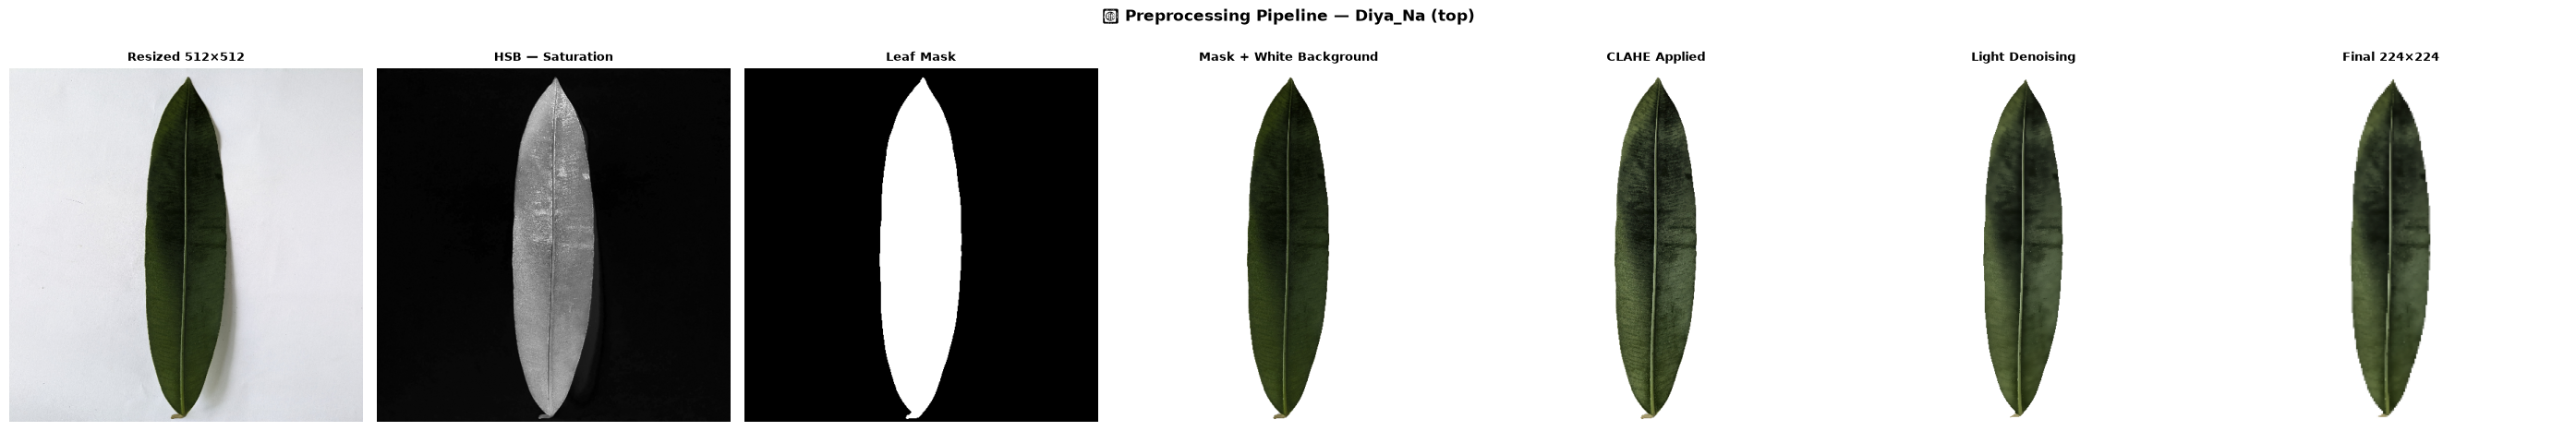

👉 White patches surviving?  Lower bridge_break_px in segment_leaf() (Cell 5)
👉 Shadow still visible?     Lower dark_v_thresh in segment_leaf() (Cell 5)
👉 Real leaf tissue cut?     Raise dark_v_thresh, or try segment_leaf_rembg() (Cell 5b)


In [6]:
def run_and_collect_steps(image_bgr, use_rembg=False):
    img = cv2.resize(image_bgr, WORK_SIZE)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    saturation_channel = hsv[:, :, 1]

    mask      = segment_leaf_rembg(img) if use_rembg else segment_leaf(img)
    no_bg     = remove_background(img, mask)
    clahe_img = apply_clahe(no_bg)
    denoised  = apply_light_denoise(clahe_img, mask)
    final     = cv2.resize(denoised, TARGET_SIZE)

    return [
        (bgr2rgb(img),       'Resized 512×512'),
        (saturation_channel, 'HSB — Saturation'),
        (mask,               'Leaf Mask'),
        (bgr2rgb(no_bg),     'Mask + White Background'),
        (bgr2rgb(clahe_img), 'CLAHE Applied'),
        (bgr2rgb(denoised),  'Light Denoising'),
        (bgr2rgb(final),     'Final 224×224'),
    ]


sample_species = species_list[0]
sample_view    = VIEWS[0]
sample_imgs    = get_images(AUGMENTED_PATH, sample_species, sample_view)

if not sample_imgs:
    print(f'⚠️  No images found in {AUGMENTED_PATH}/{sample_species}/{sample_view}/')
else:
    sample_bgr = cv2.imread(random.choice(sample_imgs))
    steps = run_and_collect_steps(sample_bgr, use_rembg=False)   # set True to preview the rembg alternative

    fig, axes = plt.subplots(1, len(steps), figsize=(28, 5))
    fig.suptitle(f'🌿 Preprocessing Pipeline — {sample_species} ({sample_view})',
                 fontsize=12, fontweight='bold')
    for ax, (img_step, title) in zip(axes, steps):
        ax.imshow(img_step, cmap='gray' if len(img_step.shape) == 2 else None)
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'{LOGS_PATH}/02b_preprocessing_all_steps.png', bbox_inches='tight', dpi=120)
    plt.show()

    print('👉 White patches surviving?  Lower bridge_break_px in segment_leaf() (Cell 5)')
    print('👉 Shadow still visible?     Lower dark_v_thresh in segment_leaf() (Cell 5)')
    print('👉 Real leaf tissue cut?     Raise dark_v_thresh, or try segment_leaf_rembg() (Cell 5b)')

## Cell 8 — Quality Control
Samples 5 images per species/view before running the full dataset

In [13]:
print('🔍 QUALITY CONTROL — Sampling 5 images per species/view')
print('=' * 62)

qc_results = []
for species in species_list:
    for view in VIEWS:
        imgs = get_images(AUGMENTED_PATH, species, view)[:5]
        if not imgs:
            print(f'  ⚠️  No images: {species}/{view}')
            continue
        for img_path in imgs:
            img = cv2.imread(img_path)
            if img is None:
                continue
            result = preprocess_image(img)
            if result is not None:
                gray = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)
                coverage = (gray < 250).sum() / gray.size * 100
                status = 'PASS' if 2 < coverage < 95 else 'FAIL'
            else:
                coverage, status = 0.0, 'FAIL'
            qc_results.append({'species': species, 'view': view,
                                'file': os.path.basename(img_path),
                                'coverage': round(coverage, 1), 'status': status})

qc_df = pd.DataFrame(qc_results)
pass_rate = (qc_df.status == 'PASS').mean() * 100

print(f'\n  Total sampled : {len(qc_df)}')
print(f'  Pass rate     : {pass_rate:.1f}%')
print('\n  Per-species/view leaf coverage (avg %):')
print(qc_df.groupby(['species', 'view'])[['coverage']].mean().round(1).to_string())

if pass_rate >= 90:
    print('\n  ✅ QC PASSED — safe to run Cell 9!')
else:
    print('\n  ⚠️  QC issues found:')
    print(qc_df[qc_df.status == 'FAIL'][['species', 'view', 'file', 'coverage']])

🔍 QUALITY CONTROL — Sampling 5 images per species/view


KeyboardInterrupt: 

## Cell 9 — Run Preprocessing on Full Dataset
⚠️ Only run after Cell 8 QC passes (≥90%)

In [14]:
print('🔄 Starting preprocessing on full dataset...')
print('=' * 65)

total_saved, total_failed, total_skip = 0, 0, 0

for species in species_list:
    for view in VIEWS:
        output_path = os.path.join(PREPROCESSED_PATH, species, view)
        os.makedirs(output_path, exist_ok=True)
        imgs = get_images(AUGMENTED_PATH, species, view)
        if not imgs:
            print(f'  ⚠️  No images: {species}/{view}')
            continue

        ok = 0
        for img_path in tqdm(imgs, desc=f'  {species}/{view}'):
            img = cv2.imread(img_path)
            if img is None:
                total_skip += 1
                continue
            result = preprocess_image(img)
            if result is not None:
                fname = os.path.splitext(os.path.basename(img_path))[0]
                cv2.imwrite(os.path.join(output_path, f'{fname}_pre.jpg'), result)
                ok += 1
                total_saved += 1
            else:
                total_failed += 1
            del img, result
        gc.collect()
        print(f'  ✅ {species}/{view}: {ok} images saved')

print('=' * 65)
print(f'✅ Done! Saved: {total_saved}  Failed: {total_failed}  Skipped: {total_skip}')
print(f'   Output: {PREPROCESSED_PATH}')

🔄 Starting preprocessing on full dataset...


  Diya_Na/top: 100%|██████████| 35/35 [00:12<00:00,  2.79it/s]


  ✅ Diya_Na/top: 35 images saved


  Diya_Na/bottom: 100%|██████████| 35/35 [00:12<00:00,  2.85it/s]


  ✅ Diya_Na/bottom: 35 images saved


...

  ✅ Sudu_Koboleela/bottom: 35 images saved


  Wali_Kaha/top: 100%|██████████| 35/35 [00:06<00:00,  5.28it/s]


  ✅ Wali_Kaha/top: 35 images saved


  Wali_Kaha/bottom: 100%|██████████| 35/35 [00:05<00:00,  5.86it/s]


  ✅ Wali_Kaha/bottom: 35 images saved
✅ Done! Saved: 845  Failed: 1  Skipped: 0
   Output: C:/Users/User/Documents/UOM/L4S2/Research/preprocess2


In [34]:

# ============================================================
# CONFIG
# ============================================================
PREPROCESSED_PATH = 'C:/Users/User/Documents/UOM/L4S2/Research/preprocess2'
SPLIT_PATH        = 'C:/Users/User/Documents/UOM/L4S2/Research/split'

VIEWS = ['top', 'bottom']

N_TEST_LEAVES  = 5
N_TRAIN_LEAVES = 30

SEED = 42

# ============================================================

random.seed(SEED)


# ============================================================
# EXTRACT PHYSICAL LEAF ID
# ============================================================
def extract_leaf_id(filename):
    """
    Extracts the physical leaf ID from filenames such as:

        top (1)_pre.jpg
        top (1)_aug03_pre.jpg
        bottom (1)_pre.jpg

    The number inside parentheses identifies the physical leaf.
    Therefore, top and bottom images of the same physical leaf
    will have the same leaf ID.
    """

    match = re.search(r'\((\d+)\)', filename)

    if match is None:
        raise ValueError(
            f'Could not find a leaf ID "(n)" in filename: {filename}'
        )

    return match.group(1)


# ============================================================
# GROUP IMAGES BY PHYSICAL LEAF
# ============================================================
def group_by_leaf(image_paths):

    groups = {}

    for path in image_paths:

        filename = os.path.basename(path)

        leaf_id = extract_leaf_id(filename)

        groups.setdefault(leaf_id, []).append(path)

    return groups


# ============================================================
# GET SPECIES
# ============================================================
species_list = sorted([
    d
    for d in os.listdir(PREPROCESSED_PATH)
    if os.path.isdir(os.path.join(PREPROCESSED_PATH, d))
])


split_summary = []

# Global counter for unique filenames
test_image_counter = 1


# ============================================================
# SPLIT EACH SPECIES
# ============================================================
for species in species_list:

    print(f'\nProcessing species: {species}')

    leaf_ids_per_view = {}

    # --------------------------------------------------------
    # Group images by physical leaf for each view
    # --------------------------------------------------------
    for view in VIEWS:

        view_dir = os.path.join(
            PREPROCESSED_PATH,
            species,
            view
        )

        imgs = glob(
            os.path.join(view_dir, '*.jpg')
        )

        leaf_ids_per_view[view] = group_by_leaf(imgs)


    # --------------------------------------------------------
    # Use only leaves having BOTH top and bottom views
    # --------------------------------------------------------
    common_leaf_ids = sorted(
        set(leaf_ids_per_view['top'].keys())
        &
        set(leaf_ids_per_view['bottom'].keys())
    )


    required_leaves = N_TEST_LEAVES + N_TRAIN_LEAVES

    if len(common_leaf_ids) < required_leaves:

        print(
            f'⚠️ {species}: only {len(common_leaf_ids)} paired leaves found. '
            f'Need {required_leaves}.'
        )


    # --------------------------------------------------------
    # Randomly shuffle physical leaves
    # --------------------------------------------------------
    shuffled = common_leaf_ids.copy()

    random.shuffle(shuffled)


    test_leaves = shuffled[
        :N_TEST_LEAVES
    ]

    train_leaves = shuffled[
        N_TEST_LEAVES:
        N_TEST_LEAVES + N_TRAIN_LEAVES
    ]


    # ========================================================
    # COPY TEST AND TRAIN IMAGES
    # ========================================================
    for split_name, leaf_subset in [

        ('test', test_leaves),

        ('train', train_leaves)

    ]:

        for view in VIEWS:

            out_dir = os.path.join(

                SPLIT_PATH,

                split_name,

                species,

                view

            )

            os.makedirs(

                out_dir,

                exist_ok=True

            )


            for leaf_id in leaf_subset:

                source_images = leaf_ids_per_view[view].get(

                    leaf_id,

                    []

                )


                for src in source_images:

                    original_filename = os.path.basename(src)


                    # ====================================================
                    # TEST SET
                    # ====================================================
                    if split_name == 'test':

                        # Preserve the original file extension
                        extension = os.path.splitext(
                            original_filename
                        )[1]


                        # Create globally unique test filename
                        new_filename = (

                            f'test_{test_image_counter:06d}'

                            f'{extension}'

                        )


                        test_image_counter += 1


                    # ====================================================
                    # TRAIN SET
                    # ====================================================
                    else:

                        # Keep original training filename
                        new_filename = original_filename


                    destination = os.path.join(

                        out_dir,

                        new_filename

                    )


                    shutil.copy2(

                        src,

                        destination

                    )


    # --------------------------------------------------------
    # Save summary
    # --------------------------------------------------------
    split_summary.append({

        'species': species,

        'paired_leaves_found': len(common_leaf_ids),

        'test_leaves': len(test_leaves),

        'train_leaves': len(train_leaves)

    })


# ============================================================
# GENERATE LABEL CSV
# ============================================================
def generate_labels_csv(

    split_path,

    split_name,

    views,

    output_csv

):

    split_dir = os.path.join(

        split_path,

        split_name

    )


    species_list = sorted([

        d

        for d in os.listdir(split_dir)

        if os.path.isdir(

            os.path.join(

                split_dir,

                d

            )

        )

    ])


    rows = []


    for species in species_list:

        for view in views:


            view_dir = os.path.join(

                split_dir,

                species,

                view

            )


            if not os.path.isdir(view_dir):

                continue


            files = sorted([

                f

                for f in os.listdir(view_dir)

                if f.lower().endswith(

                    ('.jpg', '.jpeg', '.png')

                )

            ])


            for fname in files:

                rows.append({

                    'filename': fname,

                    'view': view,

                    'true_label': species

                })


    df = pd.DataFrame(rows)


    df.to_csv(

        output_csv,

        index=False

    )


    print(

        f'📄 Saved: {output_csv} '

        f'({len(df)} rows)'

    )


    return df


# ============================================================
# GENERATE TEST LABELS CSV
# ============================================================
generate_labels_csv(

    SPLIT_PATH,

    'test',

    VIEWS,

    os.path.join(

        SPLIT_PATH,

        'species_id_test_labels.csv'

    )

)


# ============================================================
# GENERATE TRAIN LABELS CSV
# ============================================================
generate_labels_csv(

    SPLIT_PATH,

    'train',

    VIEWS,

    os.path.join(

        SPLIT_PATH,

        'species_id_train_labels.csv'

    )

)


# ============================================================
# PRINT SUMMARY
# ============================================================
print(

    pd.DataFrame(

        split_summary

    ).to_string(

        index=False

    )

)


print(

    f'\n✅ Split complete.'

    f'\n📁 Output: {SPLIT_PATH}'

)
 


Processing species: Diya_Na

Processing species: Gammiris

Processing species: Ingini

Processing species: Iriveriya

Processing species: Kapparawalliya

Processing species: Kora_Kaha
⚠️ Kora_Kaha: only 34 paired leaves found. Need 35.

Processing species: Kuringchan

Processing species: Masbadda

Processing species: Na

Processing species: Rathu_Koboleela

Processing species: Sudu_Koboleela

Processing species: Wali_Kaha
📄 Saved: C:/Users/User/Documents/UOM/L4S2/Research/split\species_id_test_labels.csv (120 rows)
📄 Saved: C:/Users/User/Documents/UOM/L4S2/Research/split\species_id_train_labels.csv (718 rows)
        species  paired_leaves_found  test_leaves  train_leaves
        Diya_Na                   35            5            30
       Gammiris                   35            5            30
         Ingini                   35            5            30
      Iriveriya                   35            5            30
 Kapparawalliya                   35            5            3

## Cell 10 — Preview Preprocessed Results

In [ ]:
for species in species_list:
    for view in VIEWS:
        cls_dir = os.path.join(PREPROCESSED_PATH, species, view)
        imgs = sorted(glob(os.path.join(cls_dir, '*.jpg')))[:6]
        if not imgs:
            continue
        fig, axes = plt.subplots(1, len(imgs), figsize=(len(imgs) * 3, 4))
        fig.suptitle(f'✅ {species} ({view})', fontsize=12, fontweight='bold')
        if len(imgs) == 1:
            axes = [axes]
        for ax, fpath in zip(axes, imgs):
            ax.imshow(bgr2rgb(cv2.imread(fpath)))
            ax.set_title(os.path.basename(fpath)[:12], fontsize=7)
            ax.axis('off')
        plt.tight_layout()
        plt.show()

## Cell 11 — Summary

In [ ]:
print('📊 DATASET SUMMARY')
print('=' * 55)
for species in species_list:
    for view in VIEWS:
        aug = len(get_images(AUGMENTED_PATH, species, view))
        pre = len(glob(os.path.join(PREPROCESSED_PATH, species, view, '*.jpg')))
        print(f'  {species}/{view:<8} {aug:>4} -> {pre:>4}')
print('=' * 55)
print('📋 Next step: Run 04_Feature_Extraction.ipynb')